In [25]:
import numpy as np
import pandas as pd
import random

In [35]:
class GridCarEnv():
    def __init__(self, dims=(6,6), max_steps=30):
        self.dims = dims # (row, col)
        self.rewards = {
            'r_goal': 100, 
            'step': -1, 
            'hit_pitfall': -5,
            'hit_obstacle': -10,
            'bump_wall': -20}
        self.max_steps = max_steps
        self.start = (dims[0]-1, 0) # bottom left
        self.end = (0, dims[1]-1) # upper right
        self.positions = {'pitfalls': [(1,3),(4,1),(3,5)], 'obstacles': [(1,2),(1,4),(3,2), (4,3)]}
        self.pos = self.start
        self.reward_score = 0
        self.current_step = 0
        self.actions = { # 4 actions: 0=Up, 1=Down, 2=Left, 3=Right
            0: (-1,  0),
            1: ( 1,  0),
            2: ( 0, -1),
            3: ( 0,  1),
        }
    
    def reset(self):
        self.pos = self.start
        self.current_step = 0
        self.reward_score = 0
        return self.pos


    def step(self, move):

        reward = self.rewards['step']
        done = False
        self.current_step += 1
        if self.current_step == self.max_steps:
            done = True
            return self.pos, reward, done

        if move == 0:
            new_pos = (self.pos[0] + self.actions[0][0], self.pos[1]+ self.actions[0][1])
            if new_pos[0] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos #change position only if it is not out of bounds
        elif move == 1:
            new_pos = (self.pos[0] + self.actions[1][0], self.pos[1]+ self.actions[1][1])
            if new_pos[0] == self.dims[0]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 2:
            new_pos = (self.pos[0] + self.actions[2][0], self.pos[1]+ self.actions[2][1])
            if new_pos[1] == -1:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        elif move == 3:
            new_pos = (self.pos[0] + self.actions[3][0], self.pos[1]+ self.actions[3][1])
            if new_pos[1] == self.dims[1]:
                reward += self.rewards['bump_wall']
            elif new_pos in self.positions['obstacles']:
                reward += self.rewards['hit_obstacle']
            else:
                self.pos = new_pos
        

        if self.pos in self.positions['pitfalls']:
            self.reward_score = self.reward_score + self.rewards['hit_pitfall']
            reward += self.rewards['hit_pitfall'] 
        elif self.pos == self.end:
            reward += self.rewards['r_goal']
            done = True



        return self.pos, reward, done
    

def initialize_q_table(n_states,n_actions):
    q_table = np.zeros((n_states, n_actions))
    return q_table
def update_q_table(Q, alpha,r, gamma, a, s_old, s, dims): 
    s = s[0] * dims[1] + s[1] # is a tuple (e.g (2,3)) and needs to be indexed as an integer
    Q[s_old,a] = Q[s_old,a] + alpha * ( r + gamma * np.max(Q[s,:]) - Q[s_old,a])

    return Q


In [31]:
def train(alpha, gamma, epsilon_decay, episodes):
    reward_list = []
    epsilon = 1 # starts with full exploration
    epsilon_min = 0.01 #always explore a little
    Q = initialize_q_table(n_states, n_actions)
    success_list = [] # how many episodes reach the end position

    for i in range(episodes): # Training loop
        pos = env.reset()
        total_reward = 0
        done = False
        
        while done is not True:
            s_old = env.pos
            s_old = s_old[0] * env.dims[1] + s_old[1] # is a tuple (e.g (2,3)) and needs to be indexed as an integer

            # e-greedy policy
            if np.random.random() < epsilon:
                action = np.random.choice(len(env.actions)) #choose a random action
            else:
                action = np.argmax(Q[s_old, :])

            pos, reward, done = env.step(action)
            total_reward += reward

            Q = update_q_table(Q, alpha, reward, gamma, action, s_old, pos, env.dims)

        epsilon = max(epsilon_min, epsilon * epsilon_decay) # apply epsilon decay 
        reward_list.append(total_reward)
        success = (env.pos == env.end)
        success_list.append(success)
    #print(Q)
    success_rate = sum(success_list) / len(success_list) * 100

    return reward_list, success_rate


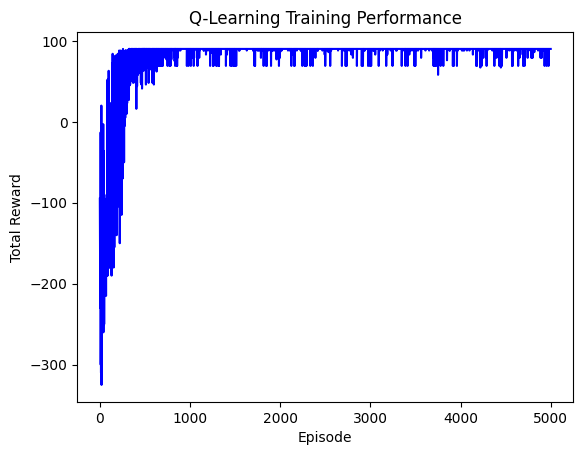

In [41]:
import matplotlib.pyplot as plt

plt.plot(reward_list, color='blue')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Training Performance')
plt.show()

In [32]:
alphas = [0.1, 0.3, 0.9]
gammas = [0.5, 0.9, 0.99]
epsilon_decay = [0.99, 0.995, 0.999]
episodes = 5000

def train_loop(alphas, gammas, epsilon_decay, episodes):

    results = {}
    for alpha in alphas:
        for gamma in gammas:
            for eps in epsilon_decay:
                reward_list, success_rate = train(alpha, gamma, eps, episodes)
                results[(alpha, gamma, eps)] = (reward_list, success_rate)
                print(f"alpha={alpha}, gamma={gamma}, epsilon={eps} | success rate={success_rate:.2f}% | avg reward={np.mean(reward_list):.2f}")
    return results


In [39]:
env = GridCarEnv()
n_states = env.dims[0] * env.dims[1] # 6*6 = 36 keeping the number of states at 36 for simplicity
n_actions = len(env.actions)  # 4   
#results = train_loop(alphas, gammas, epsilon_decay, episodes) 
reward_list, success_rate = train(0.1, 0.1, 0.995, 5000)

In [42]:
print(success_rate)

96.56


## DQN

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:

# 1. Simple Neural Network to approximate Q-values
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
from collections import deque
# 2. Replay Buffer (Standard)
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args): 
        self.buffer.append(args)
    def sample(self, batch_size): 
        return random.sample(self.buffer, batch_size)
    def __len__(self):
        return len(self.buffer)